In [1]:
# Parameters (do not containerize this cell)
# =====
# Input
# -----
# user define/upload
# param_file_seagrass_site_data        = "[Seagrass_site_data.xlsx]"
param_file_seagrass_site_data        = "Seagrass_site_data.xlsx"
# exist/download
# Step01
param_file_bottomT_p95               <- "bottomT_p95_daily_C.nc"
param_file_uo_mean_1.5m_m_s          <- "uo_mean_1.5m_m_s.nc"
param_file_vo_p90_1.5m_m_s           <- "vo_p90_1.5m_m_s.nc"
param_file_po4_mean_1.5m_mmol_m3     <- "po4_mean_monthly_1.5m_mmol_m3.nc"
param_file_pH_mean_1.5m              <- "pH_mean_monthly_1.5m.nc"
param_file_wave_height_VHM0_p95_m    <- "wave_height_p95_m.nc"
param_file_Surf_fgco2_p95_molC_m2_yr <- "Surf_fgco2_p95_molC_m2_yr.nc"
param_file_KD                        <- "S3A_OLCI_ERRNT.20160425_20241231.L3m.CU.KD.Kd_490.4km.nc"
param_file_RRS443                    <- "S3A_OLCI_ERRNT.20160425_20241231.L3m.CU.RRS.Rrs_443.4km.nc"
# Step02
param_file_For_modeling_df_shallow_carbon_density <- "For_modeling_df_shallow_carbon_density.rds"
param_file_GAM_top_reduced_SGstock   <- "GAM_top_reduced_model_SGstock.rds"

# Output
# -----
# temporary
param_file_SG_modeling_dataframe <- "SG_modeling_dataframe.csv"
# results
param_file_result <- "Seagrass_site_result.txt"

# User
# -----
param_user_email = "[the e-mail address you used to log into NaaVRE]"
# user define/upload, 1: dummy data; 0: to define/upload
param_use_dummy_data <- 1
# exist/download, 1: existing/downloaded data; 0: to download
param_use_exist_data <- 1

# Temporary
# -----
conf_directory_temporary_data <- "/tmp/data"

# MINIO
# -----
conf_minio_endpoint <- "scruffy.lab.uvalight.net:9000"
# conf_minio_endpoint <- "scruffy.lab.uvalight.net:9001"
conf_minio_region   <- "nl-uvalight"
conf_minio_bucket_public <- "naa-vre-public"
conf_minio_bucket_user   <- "naa-vre-user-data"
conf_minio_bucket_public_path <- "vl-bluecarbon"

In [2]:
# Secrets (do not containerize this cell)
# =====
library("SecretsProvider")

secretsProvider <- SecretsProvider()

secret_minio_access_key = ""
secret_minio_access_key = secretsProvider$get_secret("secret_minio_access_key")

secret_minio_secret_key = ""
secret_minio_secret_key = secretsProvider$get_secret("secret_minio_secret_key")

In [3]:
# MinIO data retriever
# =====
library("aws.s3")

Sys.setenv(
    "AWS_S3_ENDPOINT"    = conf_minio_endpoint,
    "AWS_DEFAULT_REGION" = conf_minio_region,
    "AWS_ACCESS_KEY_ID"     = secret_minio_access_key,
    "AWS_SECRET_ACCESS_KEY" = secret_minio_secret_key
)

In [4]:
# Prepare
# =====
# Load dependencies
library(tidyverse)
library(RNetCDF)

library(mgcv)
library(dplyr)
library(stringr)

# Ensure the temporary data storage directory exists
dir.create(conf_directory_temporary_data, showWarnings = FALSE)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.



In [5]:
# Seagrass site data
# =====
# Download file from bucket S3
# -----
file_seagrass_site_data <- paste(conf_directory_temporary_data, param_file_seagrass_site_data, sep="/")

if (param_use_dummy_data) {
        file_path <- paste(conf_minio_bucket_public_path, param_file_seagrass_site_data, sep="/")
        print(sprintf("Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from %s / %s", conf_minio_bucket_public, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_public, object=file_path, file=file_seagrass_site_data)
    } else {
        file_path <- paste(param_user_email, param_file_seagrass_site_data, sep="/")
        print(sprintf("Downloading data from %s / %s", conf_minio_user_bucket, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_user, object=file_path, file=file_seagrass_site_data)
}

# Open datafile with seagrass site data
# -----
Seagrass_site <- readxl::read_excel(
    file_seagrass_site_data,
    sheet = "Data", 
    col_types = c("numeric", "numeric", "text")
)

# Convert seagrass_species to a factor variable
Seagrass_site$seagrass_species <- as.factor(Seagrass_site$seagrass_species)
summary(Seagrass_site)

[1] "Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from naa-vre-public / vl-bluecarbon/Seagrass_site_data.xlsx"


[1] "/tmp/data/Seagrass_site_data.xlsx"

Warning message:
“Coercing text to numeric in A2 / R2C1: '56.0953'”
Warning message:
“Coercing text to numeric in B2 / R2C2: '14.7202'”
Warning message:
“Coercing text to numeric in A3 / R3C1: '40.62480'”
Warning message:
“Coercing text to numeric in B3 / R3C2: '0.658723'”
Warning message:
“Coercing text to numeric in A4 / R4C1: '42.42777'”
Warning message:
“Coercing text to numeric in B4 / R4C2: '27.651600'”


    latitude       longitude                                seagrass_species
 Min.   :40.62   Min.   : 0.6587   Cymodocea nodosa                 :1      
 1st Qu.:41.53   1st Qu.: 7.6895   Unspecified                      :1      
 Median :42.43   Median :14.7202   Zostera marina and Zostera noltei:1      
 Mean   :46.38   Mean   :14.3435                                            
 3rd Qu.:49.26   3rd Qu.:21.1859                                            
 Max.   :56.10   Max.   :27.6516                                            

[1] "Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from naa-vre-public / vl-bluecarbon/bottomT_p95_daily_C.nc"


[1] "/tmp/data/bottomT_p95_daily_C.nc"

[1] "Extract closest matching value based on location"


latitude,longitude,seagrass_species,bottomT_p95_C
<dbl>,<dbl>,<fct>,<dbl>
56.09530,14.720200,Unspecified,18.06645
40.62480,0.658723,Cymodocea nodosa,27.28704
42.42777,27.651600,Zostera marina and Zostera noltei,NA


[1] "Only select non-NA points"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest
<dbl>,<dbl>,<fct>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657


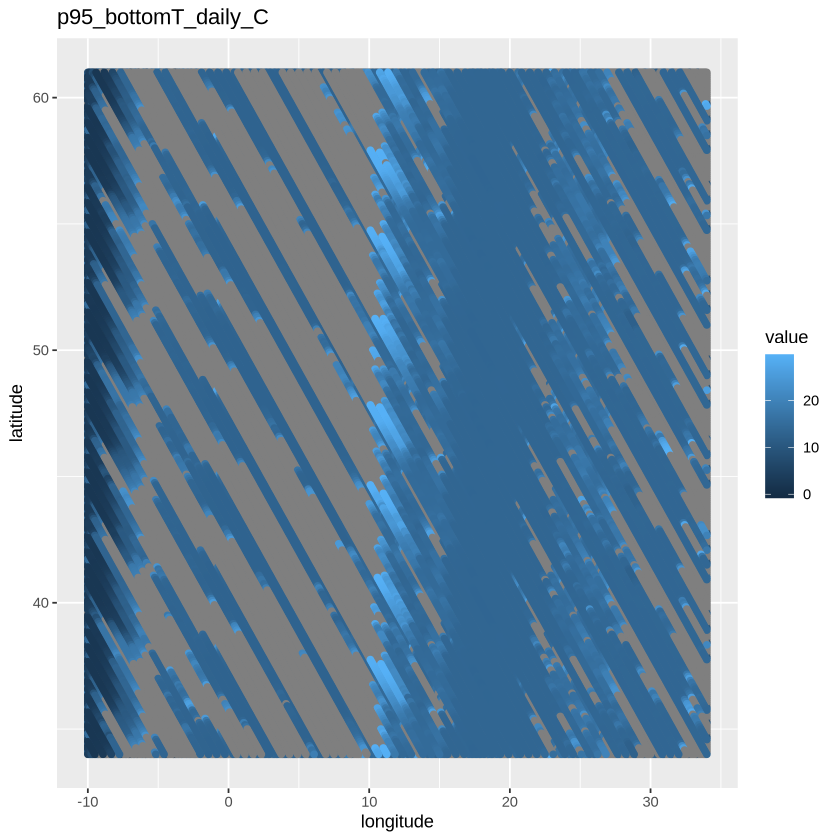

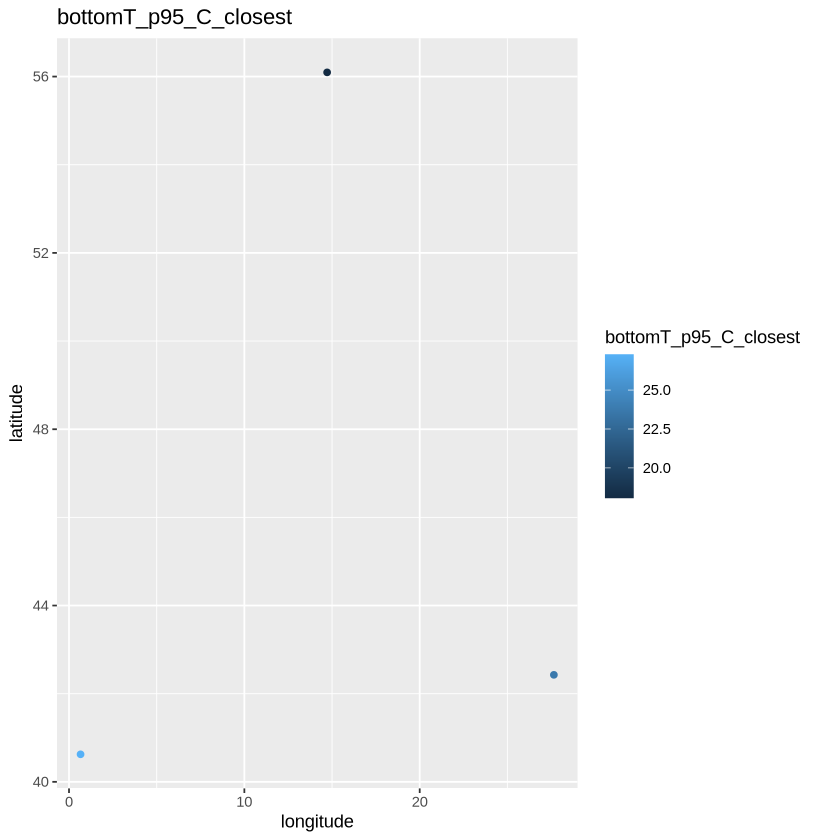

In [6]:
# Bottom_T_p95
# =====
# Download file from bucket S3
# -----
file_bottomT_p95 <- paste(conf_directory_temporary_data, param_file_bottomT_p95, sep="/")

if (param_use_dummy_data) {
        file_path <- paste(conf_minio_bucket_public_path, param_file_bottomT_p95, sep="/")
        print(sprintf("Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from %s / %s", conf_minio_bucket_public, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_public, object=file_path, file=file_bottomT_p95)
    } else {
        file_path <- paste(param_user_email, param_file_bottomT_p95, sep="/")
        print(sprintf("Downloading data from %s / %s", conf_minio_user_bucket, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_user, object=file_path, file=file_bottomT_p95)
}

# Open netcdf
# -----
bottomT_p95 <- open.nc(file_bottomT_p95)
# print.nc(bottomT_p95)

# Get data
# -----
bottomT_p95.value <- var.get.nc(bottomT_p95, "p95_bottomT_daily_C", unpack=TRUE)
bottomT_p95.lat <- var.get.nc(bottomT_p95, "latitude")
bottomT_p95.lon <- var.get.nc(bottomT_p95, "longitude")

# Check data
# -----
no2df = NULL
no2df <- rbind(no2df, data.frame(
    lat=as.vector(bottomT_p95.lat),
    lon=as.vector(bottomT_p95.lon),
    value=as.vector(bottomT_p95.value)))
ggplot(data = no2df, aes(x = lon, y = lat, col = value)) +
  geom_point() +
  labs(title = "p95_bottomT_daily_C",
       x = "longitude",
       y = "latitude")

# Close netcdf
# -----
close.nc(bottomT_p95)

print("Extract closest matching value based on location")
# -----
# This first function (extract_values) extracts values of matching sites, however this gives NAs for sites
# that appear over land given that the data product is at 0.083deg
extract_values <- function(lat_value, lon_value) {
  lat_index <- which.min(abs(bottomT_p95.lat - lat_value))
  lon_index <- which.min(abs(bottomT_p95.lon - lon_value))
  return(bottomT_p95.value[lon_index, lat_index])
}

Seagrass_site_withEnv <- Seagrass_site %>%
  rowwise() %>%
  mutate(bottomT_p95_C = extract_values(latitude, longitude))

Seagrass_site_withEnv

print("Only select non-NA points")
# -----
# This second function (extract_closest_values) extracts values of the closest sites, excluding the matching
# sites that were NAs, and instead inputing the closest available value for these
extract_closest_values <- function(lat_value, lon_value) {
  # Get indices of valid (non-NA) points in bottomT_p95.value
  valid_indices <- which(!is.na(bottomT_p95.value), arr.ind = TRUE)
  
  # Extract the corresponding valid latitude and longitude values
  valid_Lat <- bottomT_p95.lat[valid_indices[, 2]]  # lat corresponds to columns
  valid_Lon <- bottomT_p95.lon[valid_indices[, 1]]  # lon corresponds to rows
  
  # Calculate distances to the target point for valid locations
  distances <- sqrt((valid_Lat - lat_value)^2 + (valid_Lon - lon_value)^2)
  
  # Find the index of the closest valid point
  closest_valid_index <- valid_indices[which.min(distances), ]
  
  # Retrieve the corresponding value from bottomT_p95.value
  value_at_closest <- bottomT_p95.value[closest_valid_index[1], closest_valid_index[2]]
  
  return(value_at_closest)
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(bottomT_p95_C_closest = extract_closest_values(latitude, longitude))

# Check data
# -----
Seagrass_site_withEnv

ggplot(data = Seagrass_site_withEnv, aes(x = longitude, y = latitude, col = bottomT_p95_C_closest)) +
  geom_point() +
  labs(title = "bottomT_p95_C_closest",
       x = "longitude",
       y = "latitude")

[1] "Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from naa-vre-public / vl-bluecarbon/uo_mean_1.5m_m_s.nc"


[1] "/tmp/data/uo_mean_1.5m_m_s.nc"

[1] "Extract closest matching value based on location"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA


[1] "Only select non-NA points"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05


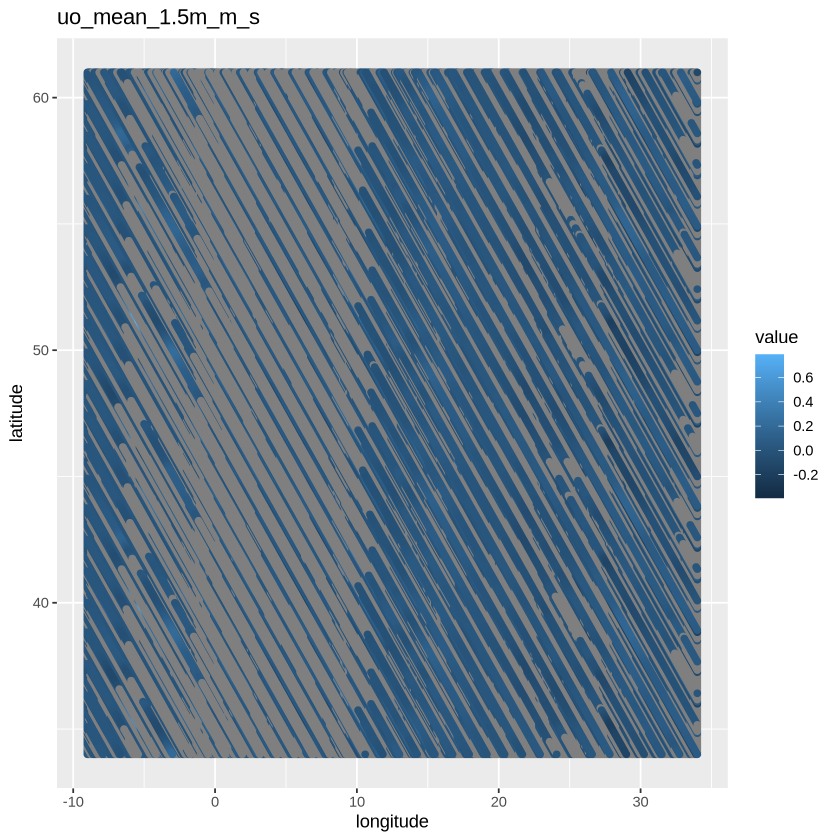

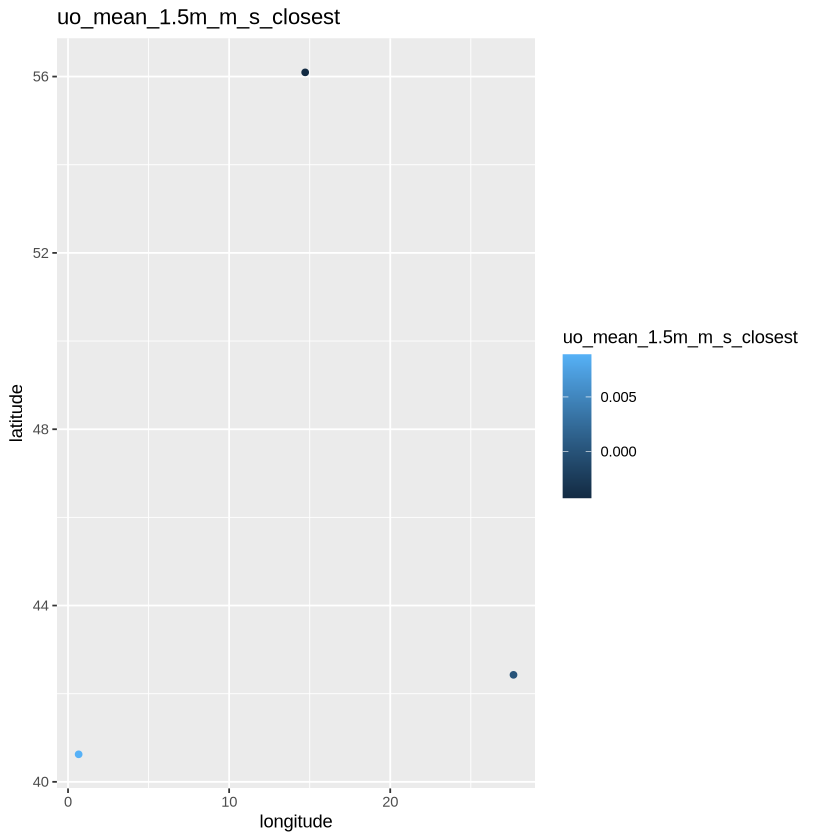

In [7]:
# Uo_mean
# =====
# Download file from bucket S3
# -----
file_uo_mean_1.5m_m_s <- paste(conf_directory_temporary_data, param_file_uo_mean_1.5m_m_s, sep="/")

if (param_use_dummy_data) {
        file_path <- paste(conf_minio_bucket_public_path, param_file_uo_mean_1.5m_m_s, sep="/")
        print(sprintf("Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from %s / %s", conf_minio_bucket_public, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_public, object=file_path, file=file_uo_mean_1.5m_m_s)
    } else {
        file_path <- paste(param_user_email, param_file_uo_mean_1.5m_m_s, sep="/")
        print(sprintf("Downloading data from %s / %s", conf_minio_user_bucket, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_user, object=file_path, file=file_uo_mean_1.5m_m_s)
}

# Open netcdf
# -----
uo_mean_1.5m_m_s <- open.nc(file_uo_mean_1.5m_m_s)
# print.nc(uo_mean_1.5m_m_s)

# Get data
uo_mean_1.5m.value <- var.get.nc(uo_mean_1.5m_m_s, 'uo_mean_1.5m_m_s', unpack=TRUE)
uo_mean_1.5m.lat <- var.get.nc(uo_mean_1.5m_m_s, 'latitude')
uo_mean_1.5m.lon <- var.get.nc(uo_mean_1.5m_m_s, 'longitude')

# Check data
no2df = NULL
no2df <- rbind(no2df, data.frame(
    lat=as.vector(uo_mean_1.5m.lat),
    lon=as.vector(uo_mean_1.5m.lon),
    value=as.vector(uo_mean_1.5m.value)))
ggplot(data = no2df, aes(x = lon, y = lat, col = value)) +
  geom_point() +
  labs(title = "uo_mean_1.5m_m_s",
       x = "longitude",
       y = "latitude")

# Close netcdf
close.nc(uo_mean_1.5m_m_s)

# Start analysis
print("Extract closest matching value based on location")
extract_values <- function(lat_value, lon_value) {
  lat_index <- which.min(abs(uo_mean_1.5m.lat - lat_value))
  lon_index <- which.min(abs(uo_mean_1.5m.lon - lon_value))
  return(uo_mean_1.5m.value[lon_index, lat_index])
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(uo_mean_1.5m_m_s = extract_values(latitude, longitude))

Seagrass_site_withEnv

print("Only select non-NA points")
extract_closest_values <- function(lat_value, lon_value) {
  # Get indices of valid (non-NA) points in uo_mean_1.5m.value
  valid_indices <- which(!is.na(uo_mean_1.5m.value), arr.ind = TRUE)
  
  # Extract the corresponding valid latitude and longitude values
  valid_Lat <- uo_mean_1.5m.lat[valid_indices[, 2]]  # lat corresponds to columns
  valid_Lon <- uo_mean_1.5m.lon[valid_indices[, 1]]  # lon corresponds to rows
  
  # Calculate distances to the target point for valid locations
  distances <- sqrt((valid_Lat - lat_value)^2 + (valid_Lon - lon_value)^2)
  
  # Find the index of the closest valid point
  closest_valid_index <- valid_indices[which.min(distances), ]
  
  # Retrieve the corresponding value
  value_at_closest <- uo_mean_1.5m.value[closest_valid_index[1], closest_valid_index[2]]
  return(value_at_closest)
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(uo_mean_1.5m_m_s_closest = extract_closest_values(latitude, longitude))

# Check data
# -----
Seagrass_site_withEnv

ggplot(data = Seagrass_site_withEnv, aes(x = longitude, y = latitude, col = uo_mean_1.5m_m_s_closest)) +
  geom_point() +
  labs(title = "uo_mean_1.5m_m_s_closest",
       x = "longitude",
       y = "latitude")

[1] "Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from naa-vre-public / vl-bluecarbon/vo_p90_1.5m_m_s.nc"


[1] "/tmp/data/vo_p90_1.5m_m_s.nc"

[1] "Extract closest matching value based on location"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA


[1] "Only select non-NA points"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s,vo_p90_1.5m_m_s_closest
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272,0.090212718
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333,0.021973327
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA,0.003540147


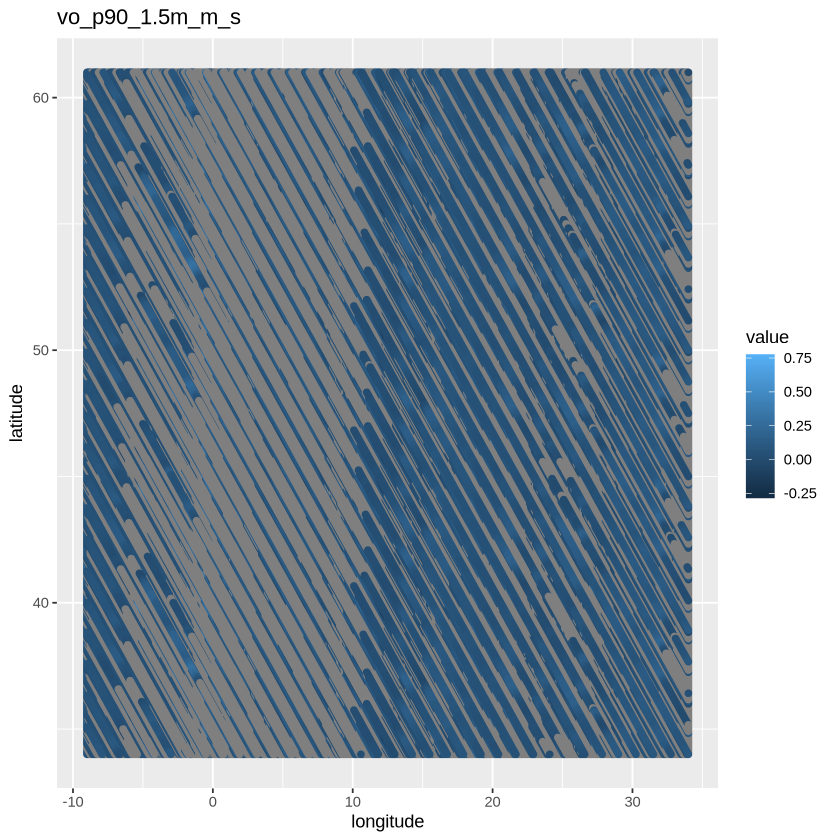

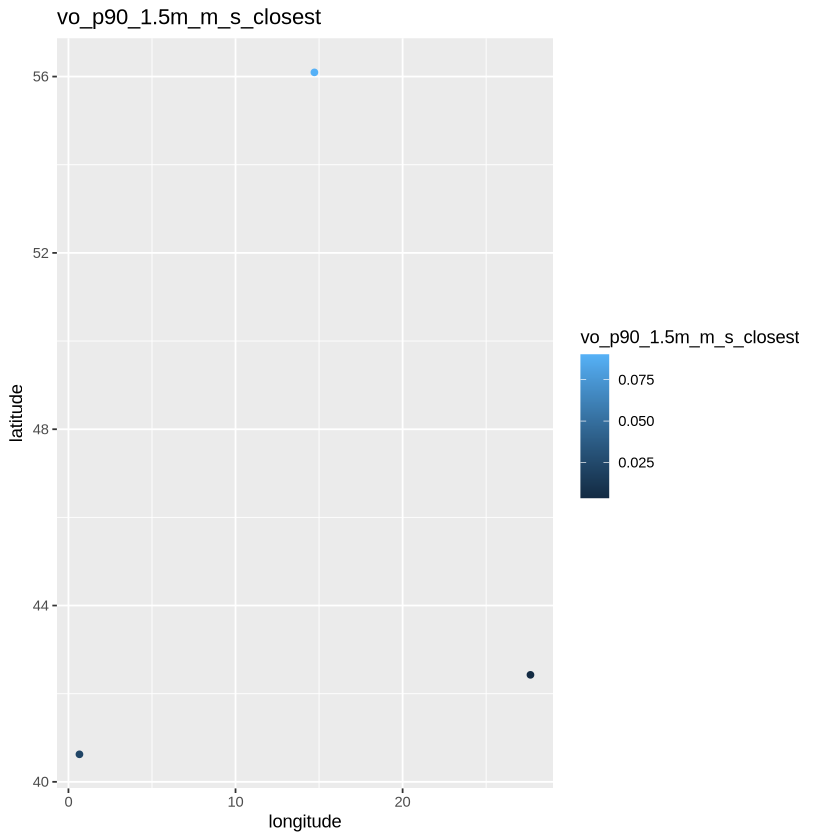

In [8]:
# Vo_p90 
# =====
# Download file from bucket S3
# -----
file_vo_p90_1.5m_m_s <- paste(conf_directory_temporary_data, param_file_vo_p90_1.5m_m_s, sep="/")

if (param_use_dummy_data) {
        file_path <- paste(conf_minio_bucket_public_path, param_file_vo_p90_1.5m_m_s, sep="/")
        print(sprintf("Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from %s / %s", conf_minio_bucket_public, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_public, object=file_path, file=file_vo_p90_1.5m_m_s)
    } else {
        file_path <- paste(param_user_email, param_file_vo_p90_1.5m_m_s, sep="/")
        print(sprintf("Downloading data from %s / %s", conf_minio_user_bucket, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_user, object=file_path, file=file_vo_p90_1.5m_m_s)
}

# Open netcdf
# -----
vo_p90_1.5m_m_s <- open.nc(file_vo_p90_1.5m_m_s)
# print.nc(vo_p90_1.5m_m_s)

# Get data
vo_p90_1.5m.value <- var.get.nc(vo_p90_1.5m_m_s, 'vo_p90_1.5m_m_s', unpack=TRUE)
vo_p90_1.5m.lat <- var.get.nc(vo_p90_1.5m_m_s, 'latitude')
vo_p90_1.5m.lon <- var.get.nc(vo_p90_1.5m_m_s, 'longitude')

# Check data
no2df = NULL
no2df <- rbind(no2df, data.frame(
    lat=as.vector(vo_p90_1.5m.lat),
    lon=as.vector(vo_p90_1.5m.lon),
    value=as.vector(vo_p90_1.5m.value)))
ggplot(data = no2df, aes(x = lon, y = lat, col = value)) +
  geom_point() +
  labs(title = "vo_p90_1.5m_m_s",
       x = "longitude",
       y = "latitude")

# Close netcdf
close.nc(vo_p90_1.5m_m_s)

# Start analysis
print("Extract closest matching value based on location")
extract_values <- function(lat_value, lon_value) {
  lat_index <- which.min(abs(vo_p90_1.5m.lat - lat_value))
  lon_index <- which.min(abs(vo_p90_1.5m.lon - lon_value))
  return(vo_p90_1.5m.value[lon_index, lat_index])
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(vo_p90_1.5m_m_s = extract_values(latitude, longitude))

Seagrass_site_withEnv

print("Only select non-NA points")
# This second function (extract_closest_values) extracts values of the closest sites, excluding the matching
# sites that were NAs, and instead inputing the closest available value for these
extract_closest_values <- function(lat_value, lon_value) {
  # Get indices of valid (non-NA) points in vo_p90_1.5m.value
  valid_indices <- which(!is.na(vo_p90_1.5m.value), arr.ind = TRUE)
  
  # Extract the corresponding valid latitude and longitude values
  valid_Lat <- vo_p90_1.5m.lat[valid_indices[, 2]]  # lat corresponds to columns
  valid_Lon <- vo_p90_1.5m.lon[valid_indices[, 1]]  # lon corresponds to rows
  
  # Calculate distances to the target point for valid locations
  distances <- sqrt((valid_Lat - lat_value)^2 + (valid_Lon - lon_value)^2)
  
  # Find the index of the closest valid point
  closest_valid_index <- valid_indices[which.min(distances), ]
  
  # Retrieve the corresponding value
  value_at_closest <- vo_p90_1.5m.value[closest_valid_index[1], closest_valid_index[2]]
  return(value_at_closest)
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(vo_p90_1.5m_m_s_closest = extract_closest_values(latitude, longitude))

# Check data
# -----
Seagrass_site_withEnv

ggplot(data = Seagrass_site_withEnv, aes(x = longitude, y = latitude, col = vo_p90_1.5m_m_s_closest)) +
  geom_point() +
  labs(title = "vo_p90_1.5m_m_s_closest",
       x = "longitude",
       y = "latitude")

[1] "Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from naa-vre-public / vl-bluecarbon/po4_mean_monthly_1.5m_mmol_m3.nc"


[1] "/tmp/data/po4_mean_monthly_1.5m_mmol_m3.nc"

[1] "Extract closest matching value based on location"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s,vo_p90_1.5m_m_s_closest,po4_mean_1.5m_mmol_m3
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272,0.090212718,0.14171837
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333,0.021973327,0.01710969
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA,0.003540147,1.40205538


[1] "Only select non-NA points"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s,vo_p90_1.5m_m_s_closest,po4_mean_1.5m_mmol_m3,po4_mean_1.5m_mmol_m3_closest
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272,0.090212718,0.14171837,0.14171837
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333,0.021973327,0.01710969,0.01710969
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA,0.003540147,1.40205538,1.40205538


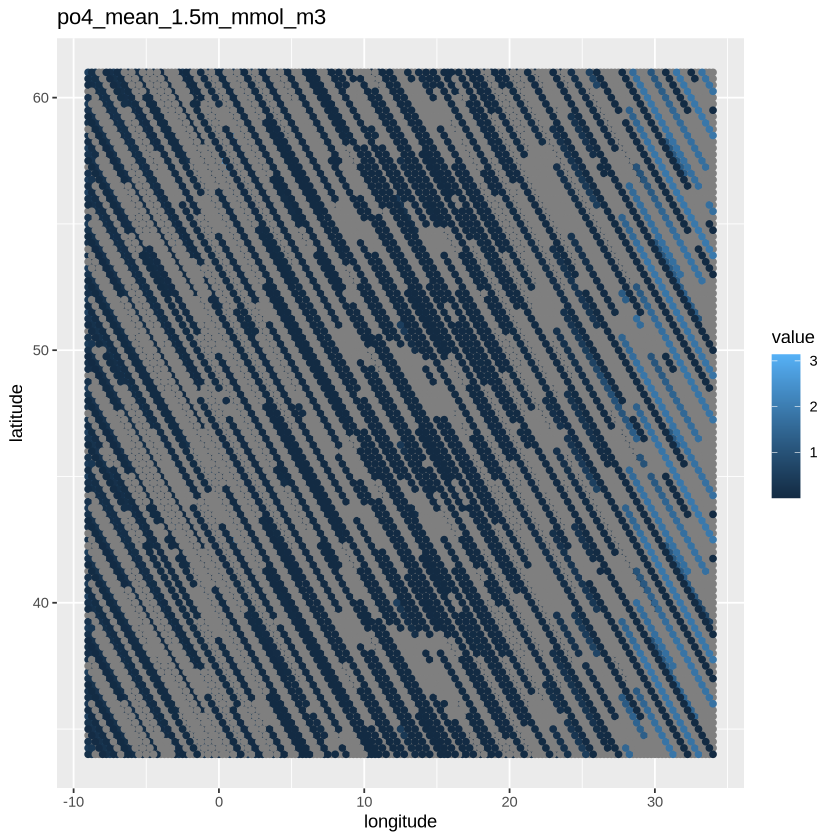

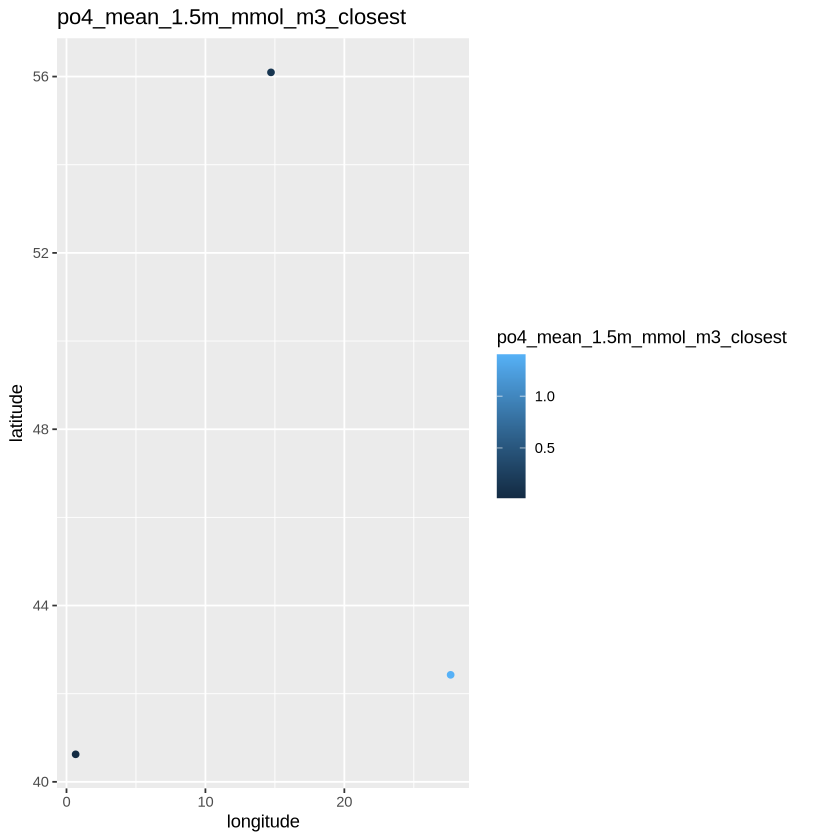

In [9]:
# Phospate_mean
# =====
# Download file from bucket S3
# -----
file_po4_mean_1.5m_mmol_m3 <- paste(conf_directory_temporary_data, param_file_po4_mean_1.5m_mmol_m3, sep="/")

if (param_use_dummy_data) {
        file_path <- paste(conf_minio_bucket_public_path, param_file_po4_mean_1.5m_mmol_m3, sep="/")
        print(sprintf("Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from %s / %s", conf_minio_bucket_public, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_public, object=file_path, file=file_po4_mean_1.5m_mmol_m3)
    } else {
        file_path <- paste(param_user_email, param_file_po4_mean_1.5m_mmol_m3, sep="/")
        print(sprintf("Downloading data from %s / %s", conf_minio_user_bucket, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_user, object=file_path, file=file_po4_mean_1.5m_mmol_m3)
}

# Open netcdf
# -----
po4_mean_1.5m_mmol_m3 <- open.nc(file_po4_mean_1.5m_mmol_m3)
# print.nc(po4_mean_1.5m_mmol_m3)

# Get data
po4_mean.value <- var.get.nc(po4_mean_1.5m_mmol_m3, 'po4_mean_1.5m_mmol_m3', unpack=TRUE)
po4_mean.lat <- var.get.nc(po4_mean_1.5m_mmol_m3, 'latitude')
po4_mean.lon <- var.get.nc(po4_mean_1.5m_mmol_m3, 'longitude')

# Check data
no2df = NULL
no2df <- rbind(no2df, data.frame(
    lat=as.vector(po4_mean.lat),
    lon=as.vector(po4_mean.lon),
    value=as.vector(po4_mean.value)))
ggplot(data = no2df, aes(x = lon, y = lat, col = value)) +
  geom_point() +
  labs(title = "po4_mean_1.5m_mmol_m3",
       x = "longitude",
       y = "latitude")

# Close netcdf
close.nc(po4_mean_1.5m_mmol_m3) #close file

# Start analysis
print("Extract closest matching value based on location")
extract_values <- function(lat_value, lon_value) {
  lat_index <- which.min(abs(po4_mean.lat - lat_value))
  lon_index <- which.min(abs(po4_mean.lon - lon_value))
  return(po4_mean.value[lon_index, lat_index])
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(po4_mean_1.5m_mmol_m3 = extract_values(latitude, longitude))

Seagrass_site_withEnv

print("Only select non-NA points")
# This second function (extract_closest_values) extracts values of the closest sites, excluding the matching
# sites that were NAs, and instead inputing the closest available value for these
extract_closest_values <- function(lat_value, lon_value) {
  # Get indices of valid (non-NA) points in po4_mean.value
  valid_indices <- which(!is.na(po4_mean.value), arr.ind = TRUE)
  
  # Extract the corresponding valid latitude and longitude values
  valid_Lat <- po4_mean.lat[valid_indices[, 2]]  # lat corresponds to columns
  valid_Lon <- po4_mean.lon[valid_indices[, 1]]  # lon corresponds to rows
  
  # Calculate distances to the target point for valid locations
  distances <- sqrt((valid_Lat - lat_value)^2 + (valid_Lon - lon_value)^2)
  
  # Find the index of the closest valid point
  closest_valid_index <- valid_indices[which.min(distances), ]
  
  # Retrieve the corresponding value
  value_at_closest <- po4_mean.value[closest_valid_index[1], closest_valid_index[2]]
  return(value_at_closest)
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(po4_mean_1.5m_mmol_m3_closest = extract_closest_values(latitude, longitude))

# Check data
# -----
Seagrass_site_withEnv

ggplot(data = Seagrass_site_withEnv, aes(x = longitude, y = latitude, col = po4_mean_1.5m_mmol_m3_closest)) +
  geom_point() +
  labs(title = "po4_mean_1.5m_mmol_m3_closest",
       x = "longitude",
       y = "latitude")

[1] "Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from naa-vre-public / vl-bluecarbon/pH_mean_monthly_1.5m.nc"


[1] "/tmp/data/pH_mean_monthly_1.5m.nc"

[1] "Extract closest matching value based on location"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s,vo_p90_1.5m_m_s_closest,po4_mean_1.5m_mmol_m3,po4_mean_1.5m_mmol_m3_closest,pH_mean_1.5m
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272,0.090212718,0.14171837,0.14171837,8.084583
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333,0.021973327,0.01710969,0.01710969,8.063301
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA,0.003540147,1.40205538,1.40205538,8.222274


[1] "Only select non-NA points"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s,vo_p90_1.5m_m_s_closest,po4_mean_1.5m_mmol_m3,po4_mean_1.5m_mmol_m3_closest,pH_mean_1.5m,pH_mean_1.5m_closest
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272,0.090212718,0.14171837,0.14171837,8.084583,8.084583
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333,0.021973327,0.01710969,0.01710969,8.063301,8.063301
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA,0.003540147,1.40205538,1.40205538,8.222274,8.222274


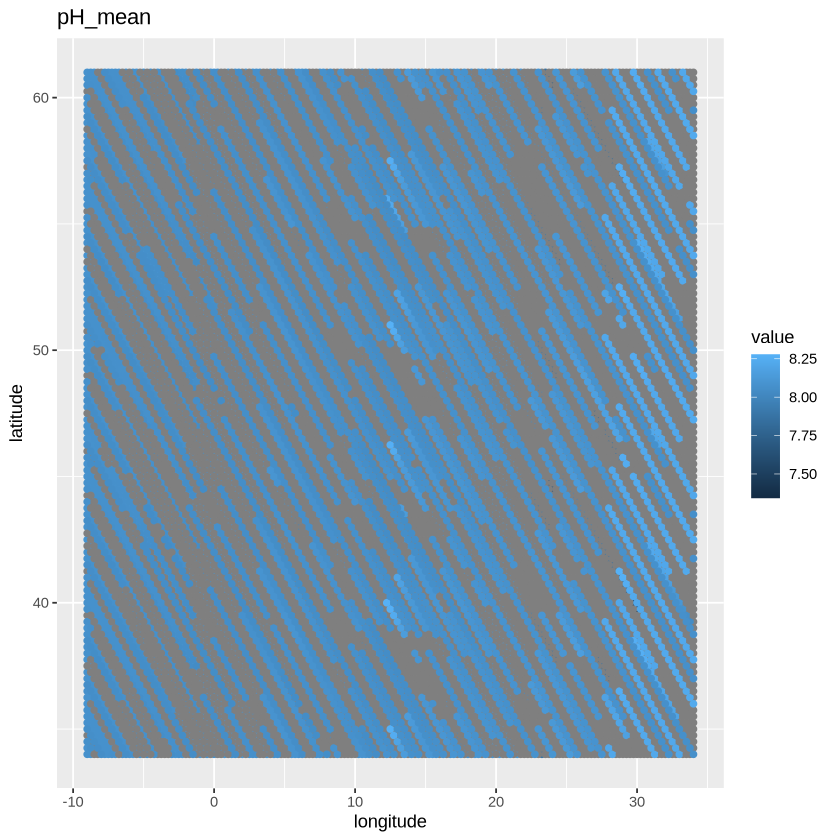

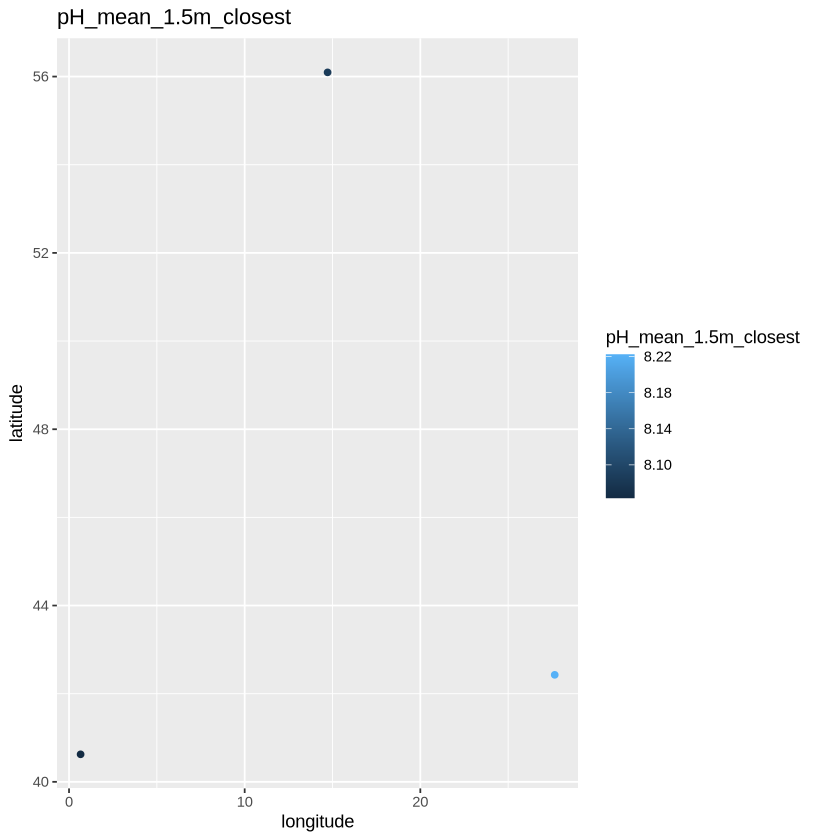

In [10]:
# pH_mean
# =====
# Download file from bucket S3
# -----
file_pH_mean_1.5m <- paste(conf_directory_temporary_data, param_file_pH_mean_1.5m, sep="/")

if (param_use_dummy_data) {
        file_path <- paste(conf_minio_bucket_public_path, param_file_pH_mean_1.5m, sep="/")
        print(sprintf("Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from %s / %s", conf_minio_bucket_public, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_public, object=file_path, file=file_pH_mean_1.5m)
    } else {
        file_path <- paste(param_user_email, param_file_pH_mean_1.5m, sep="/")
        print(sprintf("Downloading data from %s / %s", conf_minio_user_bucket, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_user, object=file_path, file=file_pH_mean_1.5m)
}

# Open netcdf
# -----
pH_mean_1.5m <- open.nc(file_pH_mean_1.5m)
# print.nc(pH_mean_1.5m)

# Get data
pH_mean.value <- var.get.nc(pH_mean_1.5m, 'pH_mean_1.5m', unpack=TRUE)
pH_mean.lat <- var.get.nc(pH_mean_1.5m, 'latitude')
pH_mean.lon <- var.get.nc(pH_mean_1.5m, 'longitude')

# Check data
no2df = NULL
no2df <- rbind(no2df, data.frame(
    lat=as.vector(pH_mean.lat),
    lon=as.vector(pH_mean.lon),
    value=as.vector(pH_mean.value)))
ggplot(data = no2df, aes(x = lon, y = lat, col = value)) +
  geom_point() +
  labs(title = "pH_mean",
       x = "longitude",
       y = "latitude")

# Close netcdf
close.nc(pH_mean_1.5m)

# Start analysis
print("Extract closest matching value based on location")
extract_values <- function(lat_value, lon_value) {
  lat_index <- which.min(abs(pH_mean.lat - lat_value))
  lon_index <- which.min(abs(pH_mean.lon - lon_value))
  return(pH_mean.value[lon_index, lat_index])
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(pH_mean_1.5m = extract_values(latitude, longitude))

Seagrass_site_withEnv

print("Only select non-NA points")
# This second function (extract_closest_values) extracts values of the closest sites, excluding the matching
# sites that were NAs, and instead inputing the closest available value for these
extract_closest_values <- function(lat_value, lon_value) {
  # Get indices of valid (non-NA) points in pH_mean.value
  valid_indices <- which(!is.na(pH_mean.value), arr.ind = TRUE)
  
  # Extract the corresponding valid latitude and longitude values
  valid_Lat <- pH_mean.lat[valid_indices[, 2]]  # lat corresponds to columns
  valid_Lon <- pH_mean.lon[valid_indices[, 1]]  # lon corresponds to rows
  
  # Calculate distances to the target point for valid locations
  distances <- sqrt((valid_Lat - lat_value)^2 + (valid_Lon - lon_value)^2)
  
  # Find the index of the closest valid point
  closest_valid_index <- valid_indices[which.min(distances), ]
  
  # Retrieve the corresponding value
  value_at_closest <- pH_mean.value[closest_valid_index[1], closest_valid_index[2]]
  return(value_at_closest)
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(pH_mean_1.5m_closest = extract_closest_values(latitude, longitude))

# Check data
# -----
Seagrass_site_withEnv

ggplot(data = Seagrass_site_withEnv, aes(x = longitude, y = latitude, col = pH_mean_1.5m_closest)) +
  geom_point() +
  labs(title = "pH_mean_1.5m_closest",
       x = "longitude",
       y = "latitude")

[1] "Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from naa-vre-public / vl-bluecarbon/wave_height_p95_m.nc"


[1] "/tmp/data/wave_height_p95_m.nc"

[1] "Extract closest matching value based on location"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s,vo_p90_1.5m_m_s_closest,po4_mean_1.5m_mmol_m3,po4_mean_1.5m_mmol_m3_closest,pH_mean_1.5m,pH_mean_1.5m_closest,wave_height_VHM0_p95_m
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272,0.090212718,0.14171837,0.14171837,8.084583,8.084583,1.37
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333,0.021973327,0.01710969,0.01710969,8.063301,8.063301,NA
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA,0.003540147,1.40205538,1.40205538,8.222274,8.222274,1.01


[1] "Only select non-NA points"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s,vo_p90_1.5m_m_s_closest,po4_mean_1.5m_mmol_m3,po4_mean_1.5m_mmol_m3_closest,pH_mean_1.5m,pH_mean_1.5m_closest,wave_height_VHM0_p95_m,wave_height_VHM0_p95_m_closest
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272,0.090212718,0.14171837,0.14171837,8.084583,8.084583,1.37,1.37
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333,0.021973327,0.01710969,0.01710969,8.063301,8.063301,NA,1.29
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA,0.003540147,1.40205538,1.40205538,8.222274,8.222274,1.01,1.01


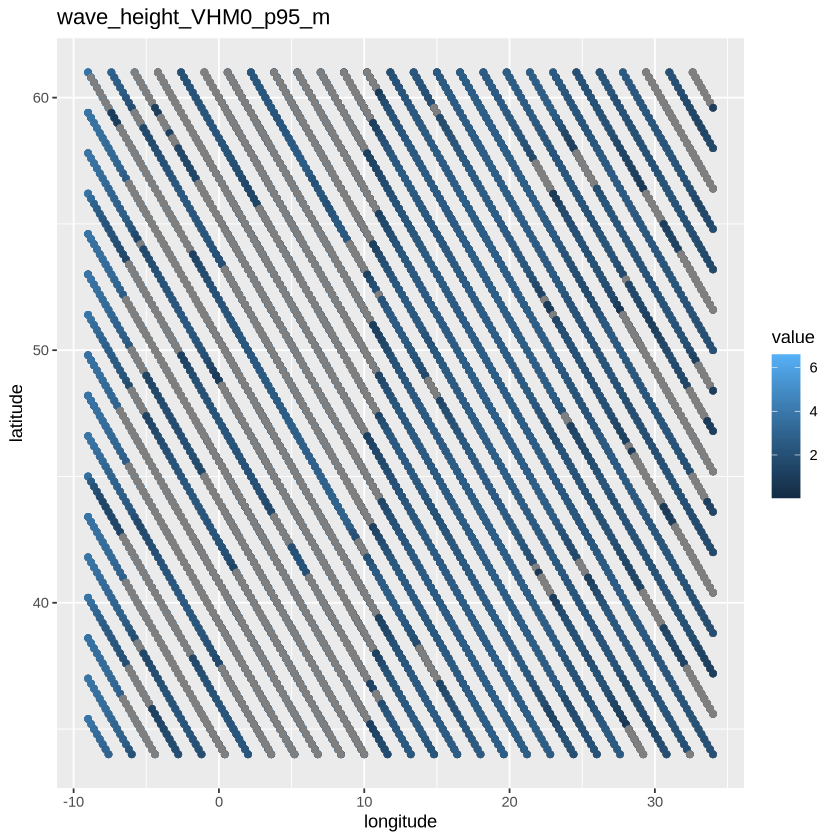

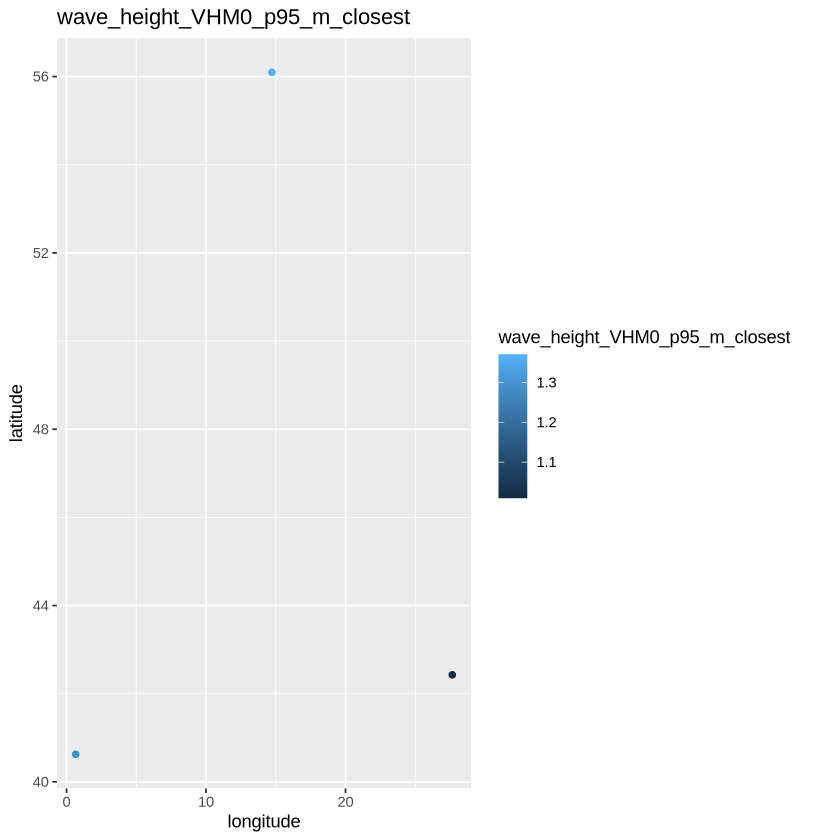

In [11]:
# VHM0_p95
# =====
# Download file from bucket S3
# -----
file_wave_height_VHM0_p95_m <- paste(conf_directory_temporary_data, param_file_wave_height_VHM0_p95_m, sep="/")

if (param_use_dummy_data) {
        file_path <- paste(conf_minio_bucket_public_path, param_file_wave_height_VHM0_p95_m, sep="/")
        print(sprintf("Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from %s / %s", conf_minio_bucket_public, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_public, object=file_path, file=file_wave_height_VHM0_p95_m)
    } else {
        file_path <- paste(param_user_email, param_file_wave_height_VHM0_p95_m, sep="/")
        print(sprintf("Downloading data from %s / %s", conf_minio_user_bucket, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_user, object=file_path, file=file_wave_height_VHM0_p95_m)
}

# Open netcdf
# -----
wave_height_VHM0_p95_m <- open.nc(file_wave_height_VHM0_p95_m)
# print.nc(wave_height_VHM0_p95_m)

# Get data
VHM0_p95_m.value <- var.get.nc(wave_height_VHM0_p95_m, 'wave_height_VHM0_p95_m', unpack=TRUE)
VHM0_p95_m.lat <- var.get.nc(wave_height_VHM0_p95_m, 'latitude')
VHM0_p95_m.lon <- var.get.nc(wave_height_VHM0_p95_m, 'longitude')

# Check data
no2df = NULL
no2df <- rbind(no2df, data.frame(
    lat=as.vector(VHM0_p95_m.lat),
    lon=as.vector(VHM0_p95_m.lon),
    value=as.vector(VHM0_p95_m.value)))
ggplot(data = no2df, aes(x = lon, y = lat, col = value)) +
  geom_point() +
  labs(title = "wave_height_VHM0_p95_m",
       x = "longitude",
       y = "latitude")

# Close netcdf
close.nc(wave_height_VHM0_p95_m)

# Start analysis
print("Extract closest matching value based on location")
extract_values <- function(lat_value, lon_value) {
  lat_index <- which.min(abs(VHM0_p95_m.lat - lat_value))
  lon_index <- which.min(abs(VHM0_p95_m.lon - lon_value))
  return(VHM0_p95_m.value[lon_index, lat_index])
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(wave_height_VHM0_p95_m = extract_values(latitude, longitude))

Seagrass_site_withEnv

print("Only select non-NA points")
extract_closest_values <- function(lat_value, lon_value) {
  # Get indices of valid (non-NA) points in VHM0_p95_m.value
  valid_indices <- which(!is.na(VHM0_p95_m.value), arr.ind = TRUE)
  
  # Extract the corresponding valid latitude and longitude values
  valid_Lat <- VHM0_p95_m.lat[valid_indices[, 2]]  # lat corresponds to columns
  valid_Lon <- VHM0_p95_m.lon[valid_indices[, 1]]  # lon corresponds to rows
  
  # Calculate distances to the target point for valid locations
  distances <- sqrt((valid_Lat - lat_value)^2 + (valid_Lon - lon_value)^2)
  
  # Find the index of the closest valid point
  closest_valid_index <- valid_indices[which.min(distances), ]
  
  # Retrieve the corresponding value
  value_at_closest <- VHM0_p95_m.value[closest_valid_index[1], closest_valid_index[2]]
  return(value_at_closest)
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(wave_height_VHM0_p95_m_closest = extract_closest_values(latitude, longitude))

# Check data
# -----
Seagrass_site_withEnv

ggplot(data = Seagrass_site_withEnv, aes(x = longitude, y = latitude, col = wave_height_VHM0_p95_m_closest)) +
  geom_point() +
  labs(title = "wave_height_VHM0_p95_m_closest",
       x = "longitude",
       y = "latitude")

[1] "Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from naa-vre-public / vl-bluecarbon/Surf_fgco2_p95_molC_m2_yr.nc"


[1] "/tmp/data/Surf_fgco2_p95_molC_m2_yr.nc"

[1] "Extract closest matching value based on location"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s,vo_p90_1.5m_m_s_closest,po4_mean_1.5m_mmol_m3,po4_mean_1.5m_mmol_m3_closest,pH_mean_1.5m,pH_mean_1.5m_closest,wave_height_VHM0_p95_m,wave_height_VHM0_p95_m_closest,Surf_fgco2_p95_molC_m2_yr
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272,0.090212718,0.14171837,0.14171837,8.084583,8.084583,1.37,1.37,NA
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333,0.021973327,0.01710969,0.01710969,8.063301,8.063301,NA,1.29,NA
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA,0.003540147,1.40205538,1.40205538,8.222274,8.222274,1.01,1.01,NA


[1] "Only select non-NA points"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s,vo_p90_1.5m_m_s_closest,po4_mean_1.5m_mmol_m3,po4_mean_1.5m_mmol_m3_closest,pH_mean_1.5m,pH_mean_1.5m_closest,wave_height_VHM0_p95_m,wave_height_VHM0_p95_m_closest,Surf_fgco2_p95_molC_m2_yr,Surf_fgco2_p95_molC_m2_yr_closest
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272,0.090212718,0.14171837,0.14171837,8.084583,8.084583,1.37,1.37,NA,4.665716
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333,0.021973327,0.01710969,0.01710969,8.063301,8.063301,NA,1.29,NA,1.291159
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA,0.003540147,1.40205538,1.40205538,8.222274,8.222274,1.01,1.01,NA,2.716748


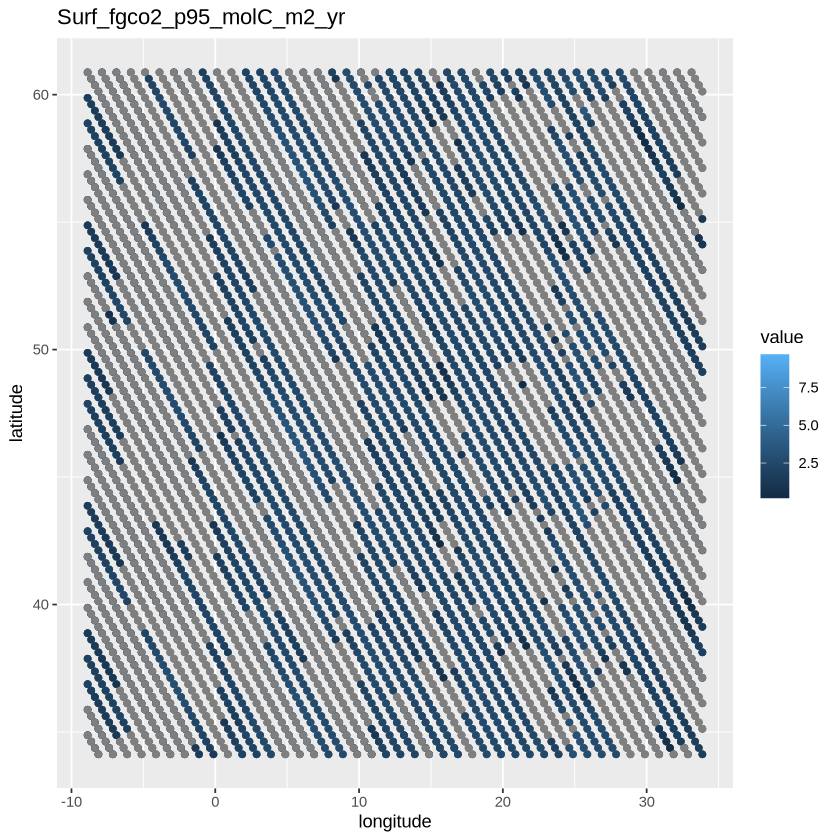

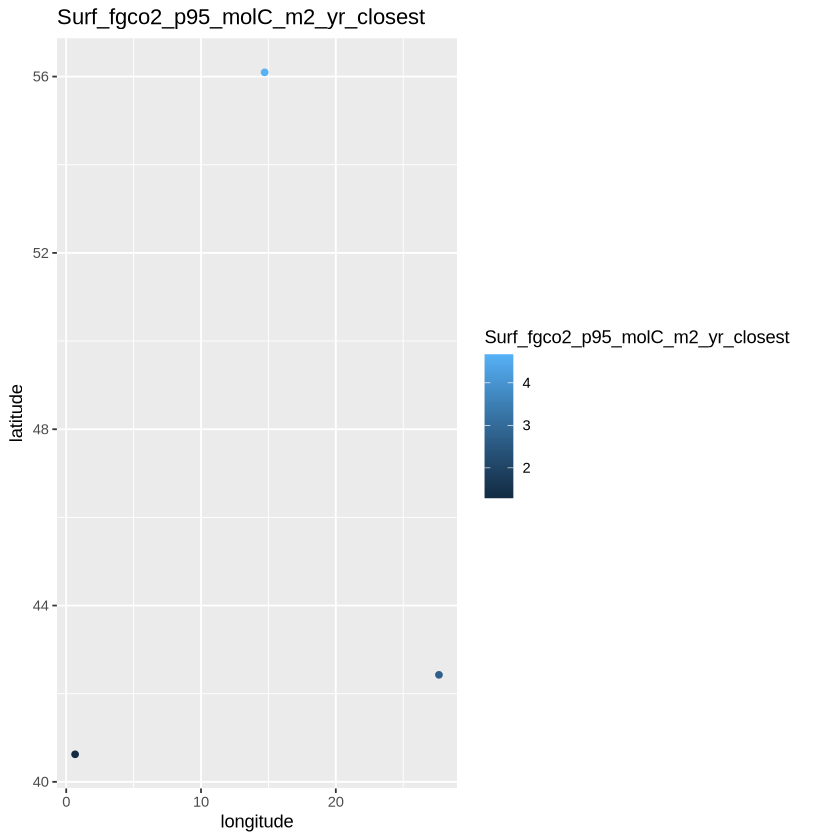

In [12]:
# fgCO2_p95
# =====
# Download file from bucket S3
# -----
file_Surf_fgco2_p95_molC_m2_yr <- paste(conf_directory_temporary_data, param_file_Surf_fgco2_p95_molC_m2_yr, sep="/")

if (param_use_dummy_data) {
        file_path <- paste(conf_minio_bucket_public_path, param_file_Surf_fgco2_p95_molC_m2_yr, sep="/")
        print(sprintf("Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from %s / %s", conf_minio_bucket_public, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_public, object=file_path, file=file_Surf_fgco2_p95_molC_m2_yr)
    } else {
        file_path <- paste(param_user_email, param_file_Surf_fgco2_p95_molC_m2_yr, sep="/")
        print(sprintf("Downloading data from %s / %s", conf_minio_user_bucket, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_user, object=file_path, file=file_Surf_fgco2_p95_molC_m2_yr)
}

# Open netcdf
# -----
Surf_fgco2_p95_molC_m2_yr <- open.nc(file_Surf_fgco2_p95_molC_m2_yr)
# print.nc(Surf_fgco2_p95_molC_m2_yr)

# Get data
Surf_fgco2_p95.value <- var.get.nc(Surf_fgco2_p95_molC_m2_yr, 'Surf_fgco2_p95_molC_m2_yr', unpack=TRUE)
Surf_fgco2_p95.lat <- var.get.nc(Surf_fgco2_p95_molC_m2_yr, 'latitude')
Surf_fgco2_p95.lon <- var.get.nc(Surf_fgco2_p95_molC_m2_yr, 'longitude')

# Check data
no2df = NULL
no2df <- rbind(no2df, data.frame(
    lat=as.vector(Surf_fgco2_p95.lat),
    lon=as.vector(Surf_fgco2_p95.lon),
    value=as.vector(Surf_fgco2_p95.value)))
ggplot(data = no2df, aes(x = lon, y = lat, col = value)) +
  geom_point() +
  labs(title = "Surf_fgco2_p95_molC_m2_yr",
       x = "longitude",
       y = "latitude")

# Close netcdf
close.nc(Surf_fgco2_p95_molC_m2_yr)

# Start analysis
print("Extract closest matching value based on location")
extract_values <- function(lat_value, lon_value) {
  lat_index <- which.min(abs(Surf_fgco2_p95.lat - lat_value))
  lon_index <- which.min(abs(Surf_fgco2_p95.lon - lon_value))
  return(Surf_fgco2_p95.value[lon_index, lat_index])
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(Surf_fgco2_p95_molC_m2_yr = extract_values(latitude, longitude))

Seagrass_site_withEnv

print("Only select non-NA points")
extract_closest_values <- function(lat_value, lon_value) {
  # Get indices of valid (non-NA) points in Surf_fgco2_p95.value
  valid_indices <- which(!is.na(Surf_fgco2_p95.value), arr.ind = TRUE)
  
  # Extract the corresponding valid latitude and longitude values
  valid_Lat <- Surf_fgco2_p95.lat[valid_indices[, 2]]  # lat corresponds to columns
  valid_Lon <- Surf_fgco2_p95.lon[valid_indices[, 1]]  # lon corresponds to rows
  
  # Calculate distances to the target point for valid locations
  distances <- sqrt((valid_Lat - lat_value)^2 + (valid_Lon - lon_value)^2)
  
  # Find the index of the closest valid point
  closest_valid_index <- valid_indices[which.min(distances), ]
  
  # Retrieve the corresponding value
  value_at_closest <- Surf_fgco2_p95.value[closest_valid_index[1], closest_valid_index[2]]
  return(value_at_closest)
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(Surf_fgco2_p95_molC_m2_yr_closest = extract_closest_values(latitude, longitude))

# Check data
# -----
Seagrass_site_withEnv

ggplot(data = Seagrass_site_withEnv, aes(x = longitude, y = latitude, col = Surf_fgco2_p95_molC_m2_yr_closest)) +
  geom_point() +
  labs(title = "Surf_fgco2_p95_molC_m2_yr_closest",
       x = "longitude",
       y = "latitude")

[1] "Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from naa-vre-public / vl-bluecarbon/S3A_OLCI_ERRNT.20160425_20241231.L3m.CU.KD.Kd_490.4km.nc"


[1] "/tmp/data/S3A_OLCI_ERRNT.20160425_20241231.L3m.CU.KD.Kd_490.4km.nc"

[1] "Extract closest matching value based on location"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s,vo_p90_1.5m_m_s_closest,po4_mean_1.5m_mmol_m3,po4_mean_1.5m_mmol_m3_closest,pH_mean_1.5m,pH_mean_1.5m_closest,wave_height_VHM0_p95_m,wave_height_VHM0_p95_m_closest,Surf_fgco2_p95_molC_m2_yr,Surf_fgco2_p95_molC_m2_yr_closest,KD
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272,0.090212718,0.14171837,0.14171837,8.084583,8.084583,1.37,1.37,NA,4.665716,1.8928
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333,0.021973327,0.01710969,0.01710969,8.063301,8.063301,NA,1.29,NA,1.291159,0.5036
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA,0.003540147,1.40205538,1.40205538,8.222274,8.222274,1.01,1.01,NA,2.716748,0.2336


[1] "Only select non-NA points"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s,vo_p90_1.5m_m_s_closest,po4_mean_1.5m_mmol_m3,po4_mean_1.5m_mmol_m3_closest,pH_mean_1.5m,pH_mean_1.5m_closest,wave_height_VHM0_p95_m,wave_height_VHM0_p95_m_closest,Surf_fgco2_p95_molC_m2_yr,Surf_fgco2_p95_molC_m2_yr_closest,KD,KD_closest
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272,0.090212718,0.14171837,0.14171837,8.084583,8.084583,1.37,1.37,NA,4.665716,1.8928,1.8928
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333,0.021973327,0.01710969,0.01710969,8.063301,8.063301,NA,1.29,NA,1.291159,0.5036,0.5036
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA,0.003540147,1.40205538,1.40205538,8.222274,8.222274,1.01,1.01,NA,2.716748,0.2336,0.2336


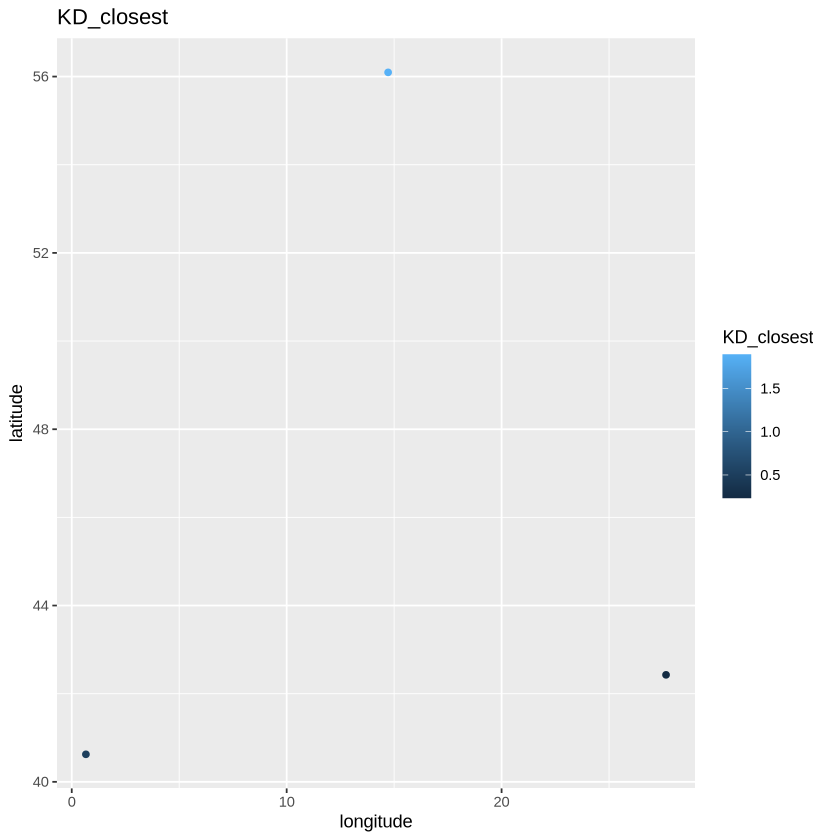

In [13]:
# KD490
# =====
# Download file from bucket S3
# -----
file_KD <- paste(conf_directory_temporary_data, param_file_KD, sep="/")

if (param_use_dummy_data) {
        file_path <- paste(conf_minio_bucket_public_path, param_file_KD, sep="/")
        print(sprintf("Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from %s / %s", conf_minio_bucket_public, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_public, object=file_path, file=file_KD)
    } else {
        file_path <- paste(param_user_email, param_file_KD, sep="/")
        print(sprintf("Downloading data from %s / %s", conf_minio_user_bucket, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_user, object=file_path, file=file_KD)
}

# Open netcdf
# -----
KD <- open.nc(file_KD)
# print.nc(KD)

# Get data
KD.Kd490 <- var.get.nc(KD, 'Kd490', unpack=TRUE)
KD.lat <- var.get.nc(KD, 'lat')
KD.lon <- var.get.nc(KD, 'lon')

# # Check data, can't plot
# no2df = NULL
# no2df <- rbind(no2df, data.frame(
#     lat=as.vector(KD.lat),
#     lon=as.vector(KD.lon),
#     value=as.vector(KD.Kd490)))
# ggplot(data = no2df, aes(x = lon, y = lat, col = value)) +
#   geom_point() +
#   labs(title = "KD",
#        x = "longitude",
#        y = "latitude")

# Close netcdf
close.nc(KD)

# Start analysis
print("Extract closest matching value based on location")
extract_values <- function(lat_value, lon_value) {
  lat_index <- which.min(abs(KD.lat - lat_value))
  lon_index <- which.min(abs(KD.lon - lon_value))
  return(KD.Kd490[lon_index, lat_index])
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(KD = extract_values(latitude, longitude))

Seagrass_site_withEnv

print("Only select non-NA points")
extract_closest_values <- function(lat_value, lon_value) {
  # Get indices of valid (non-NA) points in KD.Kd490
  valid_indices <- which(!is.na(KD.Kd490), arr.ind = TRUE)
  
  # Extract the corresponding valid latitude and longitude values
  valid_Lat <- KD.lat[valid_indices[, 2]]  # lat corresponds to columns
  valid_Lon <- KD.lon[valid_indices[, 1]]  # lon corresponds to rows
  
  # Calculate distances to the target point for valid locations
  distances <- sqrt((valid_Lat - lat_value)^2 + (valid_Lon - lon_value)^2)
  
  # Find the index of the closest valid point
  closest_valid_index <- valid_indices[which.min(distances), ]
  
  # Retrieve the corresponding value from KD.Kd490
  value_at_closest <- KD.Kd490[closest_valid_index[1], closest_valid_index[2]]
  return(value_at_closest)
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(KD_closest = extract_closest_values(latitude, longitude))

# Check data
# -----
Seagrass_site_withEnv

ggplot(data = Seagrass_site_withEnv, aes(x = longitude, y = latitude, col = KD_closest)) +
  geom_point() +
  labs(title = "KD_closest",
       x = "longitude",
       y = "latitude")

[1] "Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from naa-vre-public / vl-bluecarbon/S3A_OLCI_ERRNT.20160425_20241231.L3m.CU.RRS.Rrs_443.4km.nc"


[1] "/tmp/data/S3A_OLCI_ERRNT.20160425_20241231.L3m.CU.RRS.Rrs_443.4km.nc"

[1] "Extract closest matching value based on location"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s,vo_p90_1.5m_m_s_closest,po4_mean_1.5m_mmol_m3,po4_mean_1.5m_mmol_m3_closest,pH_mean_1.5m,pH_mean_1.5m_closest,wave_height_VHM0_p95_m,wave_height_VHM0_p95_m_closest,Surf_fgco2_p95_molC_m2_yr,Surf_fgco2_p95_molC_m2_yr_closest,KD,KD_closest,RRS443
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272,0.090212718,0.14171837,0.14171837,8.084583,8.084583,1.37,1.37,NA,4.665716,1.8928,1.8928,0.0004380009
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333,0.021973327,0.01710969,0.01710969,8.063301,8.063301,NA,1.29,NA,1.291159,0.5036,0.5036,0.0055860009
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA,0.003540147,1.40205538,1.40205538,8.222274,8.222274,1.01,1.01,NA,2.716748,0.2336,0.2336,0.0017280009


[1] "Only select non-NA points"


latitude,longitude,seagrass_species,bottomT_p95_C,bottomT_p95_C_closest,uo_mean_1.5m_m_s,uo_mean_1.5m_m_s_closest,vo_p90_1.5m_m_s,vo_p90_1.5m_m_s_closest,po4_mean_1.5m_mmol_m3,⋯,pH_mean_1.5m,pH_mean_1.5m_closest,wave_height_VHM0_p95_m,wave_height_VHM0_p95_m_closest,Surf_fgco2_p95_molC_m2_yr,Surf_fgco2_p95_molC_m2_yr_closest,KD,KD_closest,RRS443,RRS443_closest
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
56.09530,14.720200,Unspecified,18.06645,18.06645,-0.004260099,-4.260099e-03,0.09021272,0.090212718,0.14171837,⋯,8.084583,8.084583,1.37,1.37,NA,4.665716,1.8928,1.8928,0.0004380009,0.0004380009
40.62480,0.658723,Cymodocea nodosa,27.28704,27.28704,0.008891416,8.891416e-03,0.02197333,0.021973327,0.01710969,⋯,8.063301,8.063301,NA,1.29,NA,1.291159,0.5036,0.5036,0.0055860009,0.0055860009
42.42777,27.651600,Zostera marina and Zostera noltei,NA,23.66657,NA,5.516465e-05,NA,0.003540147,1.40205538,⋯,8.222274,8.222274,1.01,1.01,NA,2.716748,0.2336,0.2336,0.0017280009,0.0017280009


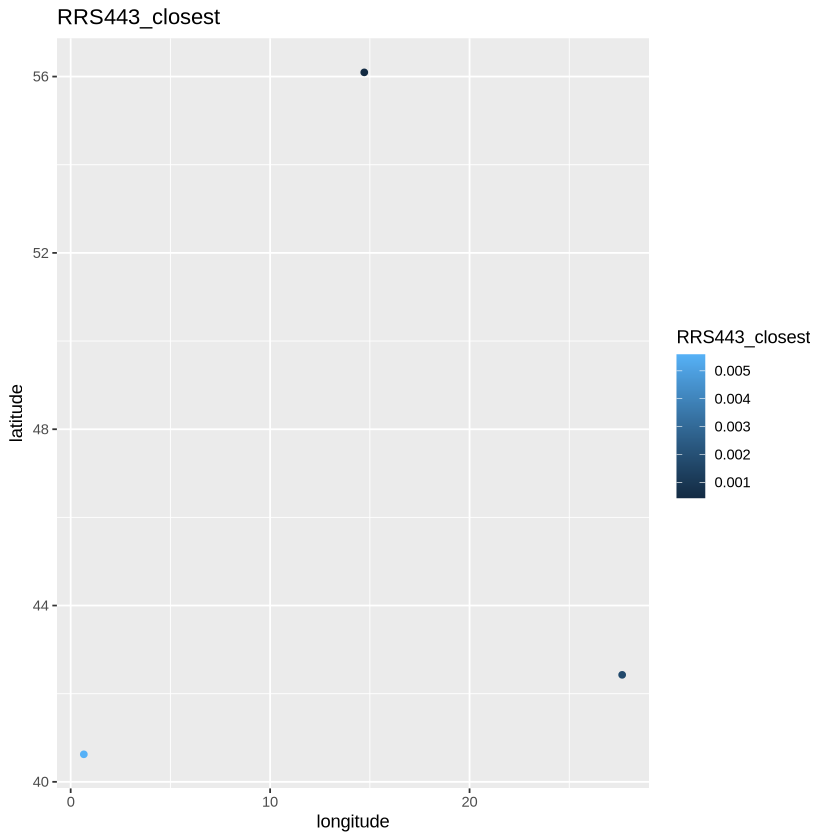

In [14]:
# RRS443
# =====
# Download file from bucket S3
# -----
file_RRS443 <- paste(conf_directory_temporary_data, param_file_RRS443, sep="/")

if (param_use_dummy_data) {
        file_path <- paste(conf_minio_bucket_public_path, param_file_RRS443, sep="/")
        print(sprintf("Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from %s / %s", conf_minio_bucket_public, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_public, object=file_path, file=file_RRS443)
    } else {
        file_path <- paste(param_user_email, param_file_RRS443, sep="/")
        print(sprintf("Downloading data from %s / %s", conf_minio_user_bucket, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_user, object=file_path, file=file_RRS443)
}

# Open netcdf
# -----
RRS443 <- open.nc(file_RRS443)
# print.nc(RRS443)

# Get data
RRS443.Rrs_443 <- var.get.nc(RRS443, 'Rrs_443', unpack=TRUE)
RRS443.lat <- var.get.nc(RRS443, 'lat')
RRS443.lon <- var.get.nc(RRS443, 'lon')

# # Check data, can't plot
# no2df = NULL
# no2df <- rbind(no2df, data.frame(
#     lat=as.vector(RRS443.lat),
#     lon=as.vector(RRS443.lon),
#     value=as.vector(RRS443.Rrs_443)))
# ggplot(data = no2df, aes(x = lon, y = lat, col = value)) +
#   geom_point() +
#   labs(title = "RRS443",
#        x = "longitude",
#        y = "latitude")

# Close netcdf
close.nc(RRS443)

# Start analysis
print("Extract closest matching value based on location")
extract_values <- function(lat_value, lon_value) {
  lat_index <- which.min(abs(RRS443.lat - lat_value))
  lon_index <- which.min(abs(RRS443.lon - lon_value))
  return(RRS443.Rrs_443[lon_index, lat_index])  # Adjust index order if needed
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(RRS443 = extract_values(latitude, longitude))

Seagrass_site_withEnv

print("Only select non-NA points")
extract_closest_values <- function(lat_value, lon_value) {
  # Get indices of valid (non-NA) points in RRS443.Rrs_443
  valid_indices <- which(!is.na(RRS443.Rrs_443), arr.ind = TRUE)
  
  # Extract the corresponding valid latitude and longitude values
  valid_Lat <- RRS443.lat[valid_indices[, 2]]  # lat corresponds to columns
  valid_Lon <- RRS443.lon[valid_indices[, 1]]  # lon corresponds to rows
  
  # Calculate distances to the target point for valid locations
  distances <- sqrt((valid_Lat - lat_value)^2 + (valid_Lon - lon_value)^2)
  
  # Find the index of the closest valid point
  closest_valid_index <- valid_indices[which.min(distances), ]
  
  # Retrieve the corresponding value
  value_at_closest <- RRS443.Rrs_443[closest_valid_index[1], closest_valid_index[2]]
  return(value_at_closest)
}

Seagrass_site_withEnv <- Seagrass_site_withEnv %>%
  rowwise() %>%
  mutate(RRS443_closest = extract_closest_values(latitude, longitude))

# Check data
# -----
Seagrass_site_withEnv

ggplot(data = Seagrass_site_withEnv, aes(x = longitude, y = latitude, col = RRS443_closest)) +
  geom_point() +
  labs(title = "RRS443_closest",
       x = "longitude",
       y = "latitude")

In [15]:
# Remove extra columns (should only retain the env. covariates with "_closest")
# =====
file_SG_modeling_dataframe <- paste(conf_directory_temporary_data, param_file_SG_modeling_dataframe, sep="/")

# Select data to save
# -----
Seagrass_site_withEnv <- Seagrass_site_withEnv %>% 
  select(-c("bottomT_p95_C", 
            "uo_mean_1.5m_m_s",
            "vo_p90_1.5m_m_s", 
            "po4_mean_1.5m_mmol_m3", 
            "pH_mean_1.5m", 
            "wave_height_VHM0_p95_m",
            "Surf_fgco2_p95_molC_m2_yr", 
            "KD", 
            "RRS443"))

# Some of the remote sensing variables can still have negative values even though they should not. 
# Set these to zero if this is the case.
Seagrass_site_withEnv$KD_closest[Seagrass_site_withEnv$KD_closest < 0] <- 0
Seagrass_site_withEnv$RRS443_closest[Seagrass_site_withEnv$RRS443_closest < 0] <- 0

# Add a variable for sediment mean depth
# For each row in the current dataframe, expand to 10 rows (with the same values), and add a new column called
# "sediment_mean_depth_cm" with the following entries "5, 15, 25, 35, 45, 55, 65, 75, 85, 95"
depths <- c(5, 15, 25, 35, 45, 55, 65, 75, 85, 95)
Seagrass_site_expanded <- Seagrass_site_withEnv[rep(1:nrow(Seagrass_site_withEnv), each = length(depths)), ]
Seagrass_site_expanded$sediment_mean_depth_cm <- rep(depths, times = nrow(Seagrass_site_withEnv))

# Check
# -----
# summary(Seagrass_site_expanded)
str(Seagrass_site_expanded) # all should be numeric, except for the seagrass_species factor variable

# Save dataframe to use for model prediction
# -----
write.csv(Seagrass_site_expanded, file_SG_modeling_dataframe, row.names = FALSE)

rowws_df [30 × 13] (S3: rowwise_df/tbl_df/tbl/data.frame)
 $ latitude                         : num [1:30] 56.1 56.1 56.1 56.1 56.1 ...
 $ longitude                        : num [1:30] 14.7 14.7 14.7 14.7 14.7 ...
 $ seagrass_species                 : Factor w/ 3 levels "Cymodocea nodosa",..: 2 2 2 2 2 2 2 2 2 2 ...
 $ bottomT_p95_C_closest            : num [1:30] 18.1 18.1 18.1 18.1 18.1 ...
 $ uo_mean_1.5m_m_s_closest         : num [1:30] -0.00426 -0.00426 -0.00426 -0.00426 -0.00426 ...
 $ vo_p90_1.5m_m_s_closest          : num [1:30] 0.0902 0.0902 0.0902 0.0902 0.0902 ...
 $ po4_mean_1.5m_mmol_m3_closest    : num [1:30] 0.142 0.142 0.142 0.142 0.142 ...
 $ pH_mean_1.5m_closest             : num [1:30] 8.08 8.08 8.08 8.08 8.08 ...
 $ wave_height_VHM0_p95_m_closest   : num [1:30] 1.37 1.37 1.37 1.37 1.37 ...
 $ Surf_fgco2_p95_molC_m2_yr_closest: num [1:30] 4.67 4.67 4.67 4.67 4.67 ...
 $ KD_closest                       : num [1:30] 1.89 1.89 1.89 1.89 1.89 ...
 $ RRS443_closest      

In [16]:
# Open csv
file_SG_modeling_dataframe <- paste(conf_directory_temporary_data, param_file_SG_modeling_dataframe, sep="/")

SG_modeling_dataframe <- read.csv(file_SG_modeling_dataframe)

# check that structure is correct (all should be numeric, except for seagrass_species which should be a factor)
str(SG_modeling_dataframe)

# Prepare dataframe
SG_modeling_dataframe <- SG_modeling_dataframe %>%
  mutate(seagrass_species = str_trim(seagrass_species),  # remove leading/trailing spaces
         seagrass_species = str_squish(seagrass_species))  # remove extra internal spaces

# SG_modeling_dataframe$seagrass_species <- as.factor(SG_modeling_dataframe$seagrass_species)
SG_modeling_dataframe$sediment_mean_depth_cm <- as.numeric(SG_modeling_dataframe$sediment_mean_depth_cm)

# Check data
# -----
# summary(SG_modeling_dataframe)
str(SG_modeling_dataframe)

'data.frame':	30 obs. of  13 variables:
 $ latitude                         : num  56.1 56.1 56.1 56.1 56.1 ...
 $ longitude                        : num  14.7 14.7 14.7 14.7 14.7 ...
 $ seagrass_species                 : chr  "Unspecified" "Unspecified" "Unspecified" "Unspecified" ...
 $ bottomT_p95_C_closest            : num  18.1 18.1 18.1 18.1 18.1 ...
 $ uo_mean_1.5m_m_s_closest         : num  -0.00426 -0.00426 -0.00426 -0.00426 -0.00426 ...
 $ vo_p90_1.5m_m_s_closest          : num  0.0902 0.0902 0.0902 0.0902 0.0902 ...
 $ po4_mean_1.5m_mmol_m3_closest    : num  0.142 0.142 0.142 0.142 0.142 ...
 $ pH_mean_1.5m_closest             : num  8.08 8.08 8.08 8.08 8.08 ...
 $ wave_height_VHM0_p95_m_closest   : num  1.37 1.37 1.37 1.37 1.37 ...
 $ Surf_fgco2_p95_molC_m2_yr_closest: num  4.67 4.67 4.67 4.67 4.67 ...
 $ KD_closest                       : num  1.89 1.89 1.89 1.89 1.89 ...
 $ RRS443_closest                   : num  0.000438 0.000438 0.000438 0.000438 0.000438 ...
 $ sedimen

In [17]:
# =====
# Download file from bucket S3
# -----
file_For_modeling_df_shallow_carbon_density <- paste(conf_directory_temporary_data, param_file_For_modeling_df_shallow_carbon_density, sep="/")

if (param_use_dummy_data) {
        file_path <- paste(conf_minio_bucket_public_path, param_file_For_modeling_df_shallow_carbon_density, sep="/")
        print(sprintf("Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from %s / %s", conf_minio_bucket_public, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_public, object=file_path, file=file_For_modeling_df_shallow_carbon_density)
    } else {
        file_path <- paste(param_user_email, param_file_For_modeling_df_shallow_carbon_density, sep="/")
        print(sprintf("Downloading data from %s / %s", conf_minio_user_bucket, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_user, object=file_path, file=file_For_modeling_df_shallow_carbon_density)
}

# Load
# -----
For_modeling_df_shallow_carbon_density <- read_rds(file_For_modeling_df_shallow_carbon_density)
str(For_modeling_df_shallow_carbon_density$random_core_variable)  # 382 levels (from 461 cores in full dataset, down to 382 unique cores)

# Check sepcies
"Zostera marina and Zostera noltei" %in% levels(For_modeling_df_shallow_carbon_density$seagrass_species)
setdiff(unique(SG_modeling_dataframe$seagrass_species), levels(For_modeling_df_shallow_carbon_density$seagrass_species))

# From SG_modeling_dataframe
raw_SG <- charToRaw(as.character(SG_modeling_dataframe$seagrass_species[SG_modeling_dataframe$seagrass_species == "Zostera marina/Zostera noltei"][1]))

# From For_modeling_df_shallow_carbon_density
raw_training <- charToRaw(as.character(For_modeling_df_shallow_carbon_density$seagrass_species[For_modeling_df_shallow_carbon_density$seagrass_species == "Zostera marina/Zostera noltei"][1]))
identical(raw_SG, raw_training)

# Match factor levels for seagrass_species
SG_modeling_dataframe$seagrass_species <- factor(
  SG_modeling_dataframe$seagrass_species,
  levels = levels(For_modeling_df_shallow_carbon_density$seagrass_species)
)

# Check data
# -----
# summary(SG_modeling_dataframe)
str(SG_modeling_dataframe)

[1] "Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from naa-vre-public / vl-bluecarbon/For_modeling_df_shallow_carbon_density.rds"


[1] "/tmp/data/For_modeling_df_shallow_carbon_density.rds"

 Factor w/ 382 levels "Ærøya_Ærøya_NA_2017_8_7_58.417_8.763_3",..: 33 33 33 43 43 43 45 45 45 39 ...


[1] TRUE

character(0)

[1] TRUE

'data.frame':	30 obs. of  13 variables:
 $ latitude                         : num  56.1 56.1 56.1 56.1 56.1 ...
 $ longitude                        : num  14.7 14.7 14.7 14.7 14.7 ...
 $ seagrass_species                 : Factor w/ 8 levels "Cymodocea nodosa",..: 4 4 4 4 4 4 4 4 4 4 ...
 $ bottomT_p95_C_closest            : num  18.1 18.1 18.1 18.1 18.1 ...
 $ uo_mean_1.5m_m_s_closest         : num  -0.00426 -0.00426 -0.00426 -0.00426 -0.00426 ...
 $ vo_p90_1.5m_m_s_closest          : num  0.0902 0.0902 0.0902 0.0902 0.0902 ...
 $ po4_mean_1.5m_mmol_m3_closest    : num  0.142 0.142 0.142 0.142 0.142 ...
 $ pH_mean_1.5m_closest             : num  8.08 8.08 8.08 8.08 8.08 ...
 $ wave_height_VHM0_p95_m_closest   : num  1.37 1.37 1.37 1.37 1.37 ...
 $ Surf_fgco2_p95_molC_m2_yr_closest: num  4.67 4.67 4.67 4.67 4.67 ...
 $ KD_closest                       : num  1.89 1.89 1.89 1.89 1.89 ...
 $ RRS443_closest                   : num  0.000438 0.000438 0.000438 0.000438 0.000438 ...
 $ sedime

In [18]:
# Use an existing placeholder level from the training data for random_core_variable
# Doesn't matter which one you use because this will be excluded in the model prediction, so I have just picked one
file_GAM_top_reduced_SGstock <- paste(conf_directory_temporary_data, param_file_GAM_top_reduced_SGstock, sep="/")

if (param_use_dummy_data) {
        file_path <- paste(conf_minio_bucket_public_path, param_file_GAM_top_reduced_SGstock, sep="/")
        print(sprintf("Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from %s / %s", conf_minio_bucket_public, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_public, object=file_path, file=file_GAM_top_reduced_SGstock)
    } else {
        file_path <- paste(param_user_email, param_file_GAM_top_reduced_SGstock, sep="/")
        print(sprintf("Downloading data from %s / %s", conf_minio_user_bucket, file_path))
        aws.s3::save_object(bucket=conf_minio_bucket_user, object=file_path, file=file_GAM_top_reduced_SGstock)
}

# Load
# -----
SG_modeling_dataframe$random_core_variable <- 
  factor(rep("Baltic Sea_Furumon_NA_2021_NA_NA_56.0953_14.7202_1.5", nrow(SG_modeling_dataframe)), 
         levels = levels(For_modeling_df_shallow_carbon_density$random_core_variable))
summary(SG_modeling_dataframe)

# Open carbon density prediction model (prepared in script: SG_carbonstock_model.R)
GAM_top_reduced_SGstock <- readRDS(file_GAM_top_reduced_SGstock)
summary(GAM_top_reduced_SGstock)

# Predict carbon density for new samples based on input variables in the "SG_modeling_dataframe.csv" spreadsheet
predicted_carbon_density <- predict(GAM_top_reduced_SGstock,
                                    newdata = SG_modeling_dataframe, 
                                    type = "response",
                                    exclude = "s(random_core_variable)")
# predicted_carbon_density_coreID_notexcluded <- predict(GAM_top_reduced_SGstock, newdata = SG_modeling_dataframe, type = "response")
# predicted_carbon_density_nocoreID <- predict(GAM_top_reduced_SGstock_nocoreID, newdata = SG_modeling_dataframe, type = "response")

# Add predictions to dataframe
SG_modeling_dataframe$predicted_carbon_density <- predicted_carbon_density

# Check data
# -----
# summary(SG_modeling_dataframe)
str(SG_modeling_dataframe)

[1] "Using dummy data for testing purposes. Set param_use_dummy_data to 0 to use your own data. Downloading data from naa-vre-public / vl-bluecarbon/GAM_top_reduced_model_SGstock.rds"


[1] "/tmp/data/GAM_top_reduced_model_SGstock.rds"

    latitude       longitude                                seagrass_species
 Min.   :40.62   Min.   : 0.6587   Cymodocea nodosa                 :10     
 1st Qu.:40.62   1st Qu.: 0.6587   Unspecified                      :10     
 Median :42.43   Median :14.7202   Zostera marina and Zostera noltei:10     
 Mean   :46.38   Mean   :14.3435   Halophila stipulacea             : 0     
 3rd Qu.:56.10   3rd Qu.:27.6516   Posidonia oceanica               : 0     
 Max.   :56.10   Max.   :27.6516   Zostera marina                   : 0     
                                   (Other)                          : 0     
 bottomT_p95_C_closest uo_mean_1.5m_m_s_closest vo_p90_1.5m_m_s_closest
 Min.   :18.07         Min.   :-4.260e-03       Min.   :0.00354        
 1st Qu.:18.07         1st Qu.:-4.260e-03       1st Qu.:0.00354        
 Median :23.67         Median : 5.516e-05       Median :0.02197        
 Mean   :23.01         Mean   : 1.562e-03       Mean   :0.03858        
 3rd Qu.:27.29         3


Family: Gamma 
Link function: log 

Formula:
carbon_density_g_c_cm3 ~ s(KD_closest) + s(RRS443_closest) + 
    s(wave_height_VHM0_p95_m_closest) + s(po4_mean_1.5m_mmol_m3_closest) + 
    s(pH_mean_1.5m_closest) + s(bottomT_p95_C_closest) + s(vo_p90_1.5m_m_s_closest) + 
    s(uo_mean_1.5m_m_s_closest) + s(Surf_fgco2_p95_molC_m2_yr_closest) + 
    s(sediment_mean_depth_cm) + seagrass_species + s(random_core_variable, 
    bs = "re")

Parametric coefficients:
                                                    Estimate Std. Error t value
(Intercept)                                         -4.62666    0.15861 -29.169
seagrass_speciesHalophila stipulacea                 0.31750    0.31210   1.017
seagrass_speciesPosidonia oceanica                   0.92490    0.16380   5.646
seagrass_speciesUnspecified                         -0.05392    0.17672  -0.305
seagrass_speciesZostera marina                      -0.39057    0.22145  -1.764
seagrass_speciesZostera marina and Cymodocea nodosa -0.688

'data.frame':	30 obs. of  15 variables:
 $ latitude                         : num  56.1 56.1 56.1 56.1 56.1 ...
 $ longitude                        : num  14.7 14.7 14.7 14.7 14.7 ...
 $ seagrass_species                 : Factor w/ 8 levels "Cymodocea nodosa",..: 4 4 4 4 4 4 4 4 4 4 ...
 $ bottomT_p95_C_closest            : num  18.1 18.1 18.1 18.1 18.1 ...
 $ uo_mean_1.5m_m_s_closest         : num  -0.00426 -0.00426 -0.00426 -0.00426 -0.00426 ...
 $ vo_p90_1.5m_m_s_closest          : num  0.0902 0.0902 0.0902 0.0902 0.0902 ...
 $ po4_mean_1.5m_mmol_m3_closest    : num  0.142 0.142 0.142 0.142 0.142 ...
 $ pH_mean_1.5m_closest             : num  8.08 8.08 8.08 8.08 8.08 ...
 $ wave_height_VHM0_p95_m_closest   : num  1.37 1.37 1.37 1.37 1.37 ...
 $ Surf_fgco2_p95_molC_m2_yr_closest: num  4.67 4.67 4.67 4.67 4.67 ...
 $ KD_closest                       : num  1.89 1.89 1.89 1.89 1.89 ...
 $ RRS443_closest                   : num  0.000438 0.000438 0.000438 0.000438 0.000438 ...
 $ sedime

In [19]:
# Calculate carbon stock in the upper 30 and 100 cm
# =====
# Calculate carbon stock per 10 cm
# Carbon stock (MgC/ha)=Carbon density (gC/cm³) × Depth (cm) × 100,000,000 (cm2/ha) ÷ 1,000,000 (g/Mg)
# Where:
#   1 hectare = 10,000 m² = 100,000,000 cm²
#   1 Mg = 1,000,000 g
SG_modeling_dataframe$predicted_carbon_stock_per_10cm = 
  SG_modeling_dataframe$predicted_carbon_density*10*100000000*(1/1000000)

# Create sample_ID column
SG_modeling_dataframe$sample_ID <- rep(1:(nrow(SG_modeling_dataframe)/10), each = 10)

# Calculate carbon stock in upper 30 and 100 cm 
SG_modeling_dataframe <- SG_modeling_dataframe %>%
  group_by(sample_ID) %>%
  mutate(
    carbon_stock_Mg_ha_upper30cm  = sum(predicted_carbon_stock_per_10cm[1:3]),
    carbon_stock_Mg_ha_upper100cm = sum(predicted_carbon_stock_per_10cm)
  ) %>%
  ungroup()

# Check data
# -----
# summary(SG_modeling_dataframe)
str(SG_modeling_dataframe)

tibble [30 × 19] (S3: tbl_df/tbl/data.frame)
 $ latitude                         : num [1:30] 56.1 56.1 56.1 56.1 56.1 ...
 $ longitude                        : num [1:30] 14.7 14.7 14.7 14.7 14.7 ...
 $ seagrass_species                 : Factor w/ 8 levels "Cymodocea nodosa",..: 4 4 4 4 4 4 4 4 4 4 ...
 $ bottomT_p95_C_closest            : num [1:30] 18.1 18.1 18.1 18.1 18.1 ...
 $ uo_mean_1.5m_m_s_closest         : num [1:30] -0.00426 -0.00426 -0.00426 -0.00426 -0.00426 ...
 $ vo_p90_1.5m_m_s_closest          : num [1:30] 0.0902 0.0902 0.0902 0.0902 0.0902 ...
 $ po4_mean_1.5m_mmol_m3_closest    : num [1:30] 0.142 0.142 0.142 0.142 0.142 ...
 $ pH_mean_1.5m_closest             : num [1:30] 8.08 8.08 8.08 8.08 8.08 ...
 $ wave_height_VHM0_p95_m_closest   : num [1:30] 1.37 1.37 1.37 1.37 1.37 ...
 $ Surf_fgco2_p95_molC_m2_yr_closest: num [1:30] 4.67 4.67 4.67 4.67 4.67 ...
 $ KD_closest                       : num [1:30] 1.89 1.89 1.89 1.89 1.89 ...
 $ RRS443_closest                   

In [20]:
# Create summary sentences
# =====
file_result <- paste(conf_directory_temporary_data, param_file_result, sep="/")

summary_sentences <- SG_modeling_dataframe %>%
  group_by(sample_ID) %>%
  slice(1) %>%  # take one row per sample
  mutate(summary = paste0(
    "For the seagrass bed at latitude ", latitude, " and longitude ", longitude, "\n",
    "The species identity ", seagrass_species, "\n",
    "The predicted carbon stock in the upper \n",
    "  - upper 30cm  of the sediment is ", format(carbon_stock_Mg_ha_upper30cm, digits=3, nsmall=3),  " Mg/ha\n",
    "  - upper 100cm of the sediment is ", format(carbon_stock_Mg_ha_upper100cm, digits=3, nsmall=3), " Mg/ha\n"
  )) %>%
  pull(summary)

# Print the summaries
cat(summary_sentences, sep = "\n")

# Save result
cat(summary_sentences, sep = "\n", file = file_result, append = TRUE)

# put_object(bucket=conf_minio_user_bucket, file=file_result, object=paste(param_user_email, param_file_result, sep="/"))

For the seagrass bed at latitude 56.0953 and longitude 14.7202
The species identity Unspecified
The predicted carbon stock in the upper 
  - upper 30cm  of the sediment is 13.998 Mg/ha
  - upper 100cm of the sediment is 49.741 Mg/ha

For the seagrass bed at latitude 40.6248 and longitude 0.658723
The species identity Cymodocea nodosa
The predicted carbon stock in the upper 
  - upper 30cm  of the sediment is 13.650 Mg/ha
  - upper 100cm of the sediment is 48.504 Mg/ha

For the seagrass bed at latitude 42.42777 and longitude 27.6516
The species identity Zostera marina and Zostera noltei
The predicted carbon stock in the upper 
  - upper 30cm  of the sediment is 3.748 Mg/ha
  - upper 100cm of the sediment is 13.318 Mg/ha

